# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
df_history = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_history.csv')

In [3]:
df_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
user_session_counts = df_history.groupby('user_id')['session_id'].nunique()
max_sessions_user = user_session_counts.idxmax()
top_user_sessions = df_history[df_history['user_id'] == max_sessions_user]
display(top_user_sessions)

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

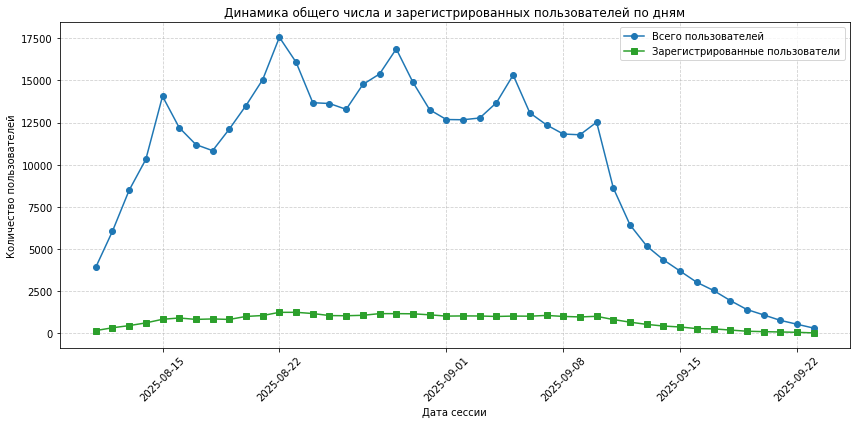

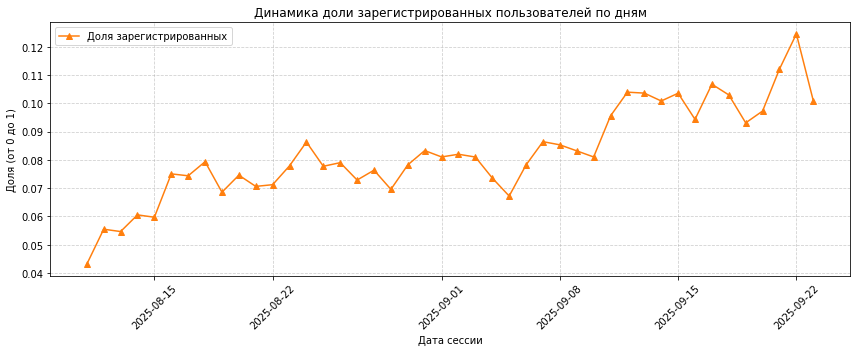

In [5]:
# Считаем общее число уникальных пользователей и число уникальных зарегистрированных
daily_data = (
    df_history.groupby("session_date")
    .agg(
        total_users=("user_id", "nunique"),
        registered_users=(
            "user_id",
            lambda x: x[
                df_history.loc[x.index, "registration_flag"] == 1
            ].nunique(),
        ),
    )
    .reset_index()
)
# Переводим дату в формат datetime 
daily_data["session_date"] = pd.to_datetime(daily_data["session_date"])
# Считаем долю зарегистрированных пользователей от общего числа
daily_data["registration_share"] = (
    daily_data["registered_users"] / daily_data["total_users"]
)
# 2. График 1: Общее число пользователей и число зарегистрированных по дням
plt.figure(figsize=(12, 6))
plt.plot(
    daily_data["session_date"],
    daily_data["total_users"],
    label="Всего пользователей",
    color="tab:blue",
    marker="o",
)
plt.plot(
    daily_data["session_date"],
    daily_data["registered_users"],
    label="Зарегистрированные пользователи",
    color="tab:green",
    marker="s",
)

plt.title("Динамика общего числа и зарегистрированных пользователей по дням")
plt.xlabel("Дата сессии")
plt.ylabel("Количество пользователей")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 3. График 2: Доля зарегистрированных пользователей по дням
plt.figure(figsize=(12, 5))
plt.plot(
    daily_data["session_date"],
    daily_data["registration_share"],
    label="Доля зарегистрированных",
    color="tab:orange",
    marker="^",
)

plt.title("Динамика доли зарегистрированных пользователей по дням")
plt.xlabel("Дата сессии")
plt.ylabel("Доля (от 0 до 1)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 8978 первых сессиях, две страницы — в 32 494 первых сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

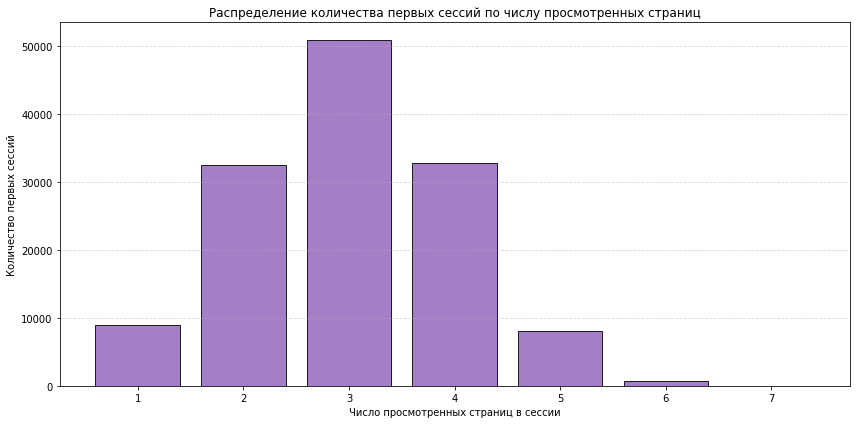

In [6]:
# 1. Отбираем только первые сессии пользователей
first_sessions = df_history[df_history["session_number"] == 1]

# 2. Считаем количество первых сессий для каждого значения просмотренных страниц
page_counts = (
    first_sessions.groupby("page_counter")["session_id"]
    .count()
    .reset_index()
)
page_counts.columns = ["page_counter", "sessions_count"]

# 3. Построение столбчатой диаграммы
plt.figure(figsize=(12, 6))
plt.bar(
    page_counts["page_counter"],
    page_counts["sessions_count"],
    color="tab:purple",
    alpha=0.85,
    edgecolor="black",
)

# Настройка внешнего вида графика
plt.title(
    "Распределение количества первых сессий по числу просмотренных страниц"
)
plt.xlabel("Число просмотренных страниц в сессии")
plt.ylabel("Количество первых сессий")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Делаем засечки на оси X целыми числами для удобства чтения
plt.xticks(page_counts["page_counter"])

plt.tight_layout()
plt.show()

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что первые сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных первых сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

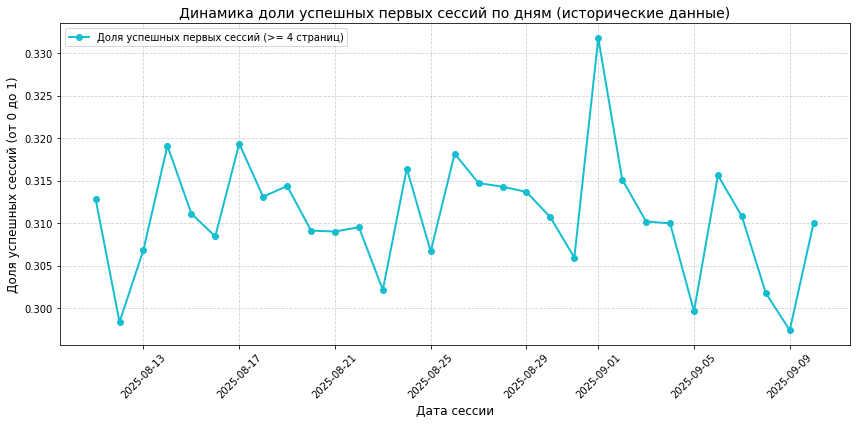

In [7]:
df_history["good_session"] = (
    df_history["page_counter"] >= 4
).astype(int)

first_sessions = df_history[df_history["session_number"] == 1].copy()
first_sessions["session_date"] = pd.to_datetime(first_sessions["session_date"])
daily_good_share = (
    first_sessions.groupby("session_date")["good_session"]
    .mean()
    .reset_index()
)

# Построение линейного графика
plt.figure(figsize=(12, 6))
plt.plot(
    daily_good_share["session_date"],
    daily_good_share["good_session"],
    color="tab:cyan",
    linewidth=2,
    marker="o",
    label="Доля успешных первых сессий (>= 4 страниц)",
)

# Настройка графика
plt.title(
    "Динамика доли успешных первых сессий по дням (исторические данные)",
    fontsize=14,
)
plt.xlabel("Дата сессии", fontsize=12)
plt.ylabel("Доля успешных сессий (от 0 до 1)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [8]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize


# Задайте параметры:
alpha = 0.05  # Уровень значимости
beta = 0.2 # Ошибка второго рода, часто 1 - мощность
power = 1-beta # Мощность теста
p = 0.3 # Базовый уровень доли
mde = 0.03 * p  # Минимальный детектируемый эффект
effect_size = proportion_effectsize(p, p + mde)

# Инициализируем класс NormalIndPower
power_analysis = NormalIndPower()

# Расчёт размера выборки
sample_size = power_analysis.solve_power(
    effect_size = effect_size,
    power = power,
    alpha = alpha,
    ratio = 1 # Равномерное распределение выборок
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [9]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
daily_users = df_history.groupby('session_date')['user_id'].nunique()

# Находим среднее количество уникальных пользователей приложения в день
avg_daily_users = daily_users.mean()

sample_size_per_group = sample_size

# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil((sample_size_per_group * 2) / avg_daily_users)


print(f"Рассчитанная длительность A/B‑теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")


Рассчитанная длительность A/B‑теста при текущем уровне трафика в 9907.363636363636 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

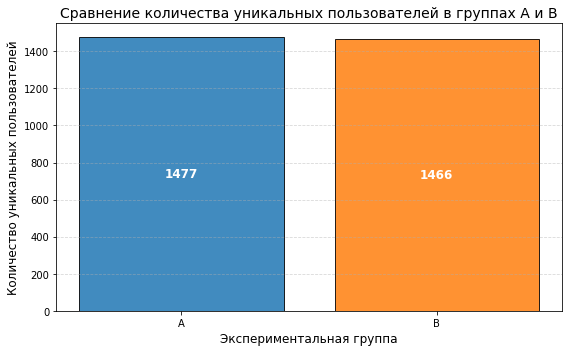

In [10]:
sessions_test_part = pd.read_csv("https://code.s3.yandex.net/datasets/sessions_project_test_part.csv")
group_sizes = sessions_test_part.groupby("test_group")["user_id"].nunique()

A = group_sizes.get("A", 0)
B = group_sizes.get("B", 0)

# Расчет по заданной формуле
p_difference = 100 * abs(A - B) / A

# Визуализация результатов 
plt.figure(figsize=(8, 5))
bars = plt.bar(
    group_sizes.index,
    group_sizes.values,
    color=["tab:blue", "tab:orange"],
    alpha=0.85,
    edgecolor="black",
)

# подписи на бары
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height / 2,
        f"{int(height)}",
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
        fontsize=12,
    )

plt.title(
    "Сравнение количества уникальных пользователей в группах A и B",
    fontsize=14,
)
plt.xlabel("Экспериментальная группа", fontsize=12)
plt.ylabel("Количество уникальных пользователей", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [11]:
users_A = set(sessions_test_part[sessions_test_part['test_group'] == 'A']['user_id'])
users_B = set(sessions_test_part[sessions_test_part['test_group'] == 'B']['user_id'])

intersecting_users = users_A.intersection(users_B)

print(f"Количество пользователей, попавших в обе группы одновременно: {len(intersecting_users)}")

if len(intersecting_users) > 0:
    print("Внимание! Обнаружено пересечение групп. Список первых 10 ID:", list(intersecting_users)[:10])
else:
    print("Проверка успешна: пользователи не пересекаются между группами.")


Количество пользователей, попавших в обе группы одновременно: 0
Проверка успешна: пользователи не пересекаются между группами.


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


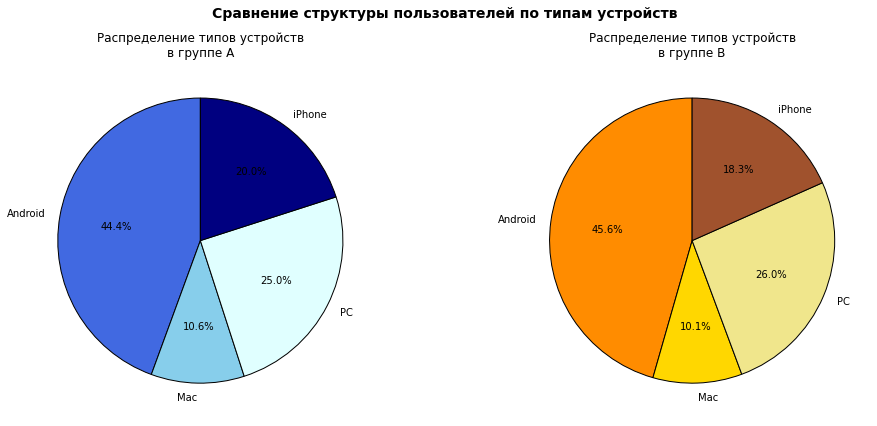

In [12]:
unique_users_devices = sessions_test_part.drop_duplicates(
    subset=["user_id", "test_group"]
)

#  Считаем распределение устройств внутри группы A
device_dist_A = (
    unique_users_devices[unique_users_devices["test_group"] == "A"]["device"]
    .value_counts(normalize=True)
    .sort_index()
)

# Считаем распределение устройств внутри группы B
device_dist_B = (
    unique_users_devices[unique_users_devices["test_group"] == "B"]["device"]
    .value_counts(normalize=True)
    .sort_index()
)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Диаграмма для группы A 
ax1.pie(
    device_dist_A.values,
    labels=device_dist_A.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["royalblue", "skyblue", "lightcyan", "navy"][: len(device_dist_A)],
    wedgeprops={"edgecolor": "black", "linewidth": 1},
)
ax1.set_title("Распределение типов устройств\nв группе A", fontsize=12)

# Диаграмма для группы B 
ax2.pie(
    device_dist_B.values,
    labels=device_dist_B.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["darkorange", "gold", "khaki", "sienna"][: len(device_dist_B)],
    wedgeprops={"edgecolor": "black", "linewidth": 1},
)
ax2.set_title("Распределение типов устройств\nв группе B", fontsize=12)

plt.suptitle(
    "Сравнение структуры пользователей по типам устройств",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

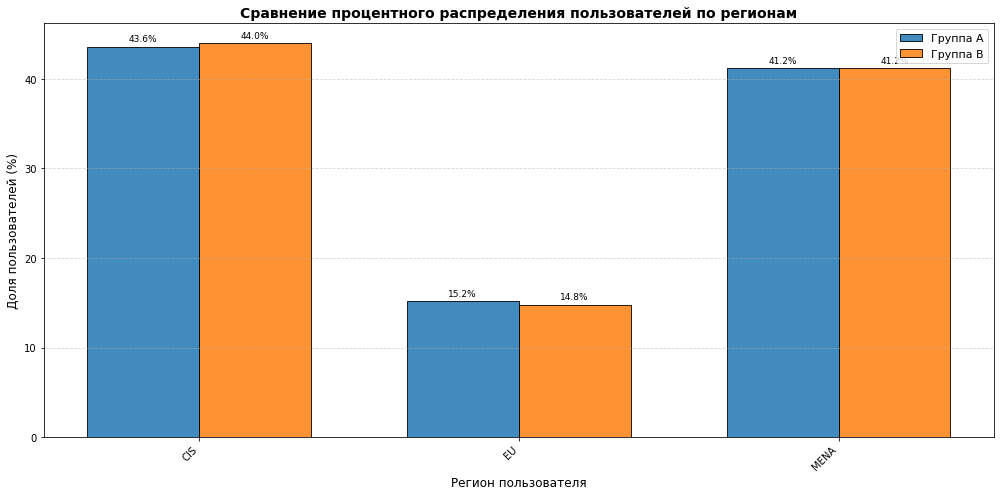

In [13]:
unique_users_regions = sessions_test_part.drop_duplicates(
    subset=["user_id", "test_group"]
)

region_dist_A = (
    unique_users_regions[unique_users_regions["test_group"] == "A"]["region"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

region_dist_B = (
    unique_users_regions[unique_users_regions["test_group"] == "B"]["region"]
    .value_counts(normalize=True)
    .sort_index()
    * 100
)

all_regions = sorted(
    list(set(region_dist_A.index).union(set(region_dist_B.index)))
)

shares_A = [region_dist_A.get(r, 0) for r in all_regions]
shares_B = [region_dist_B.get(r, 0) for r in all_regions]

x = np.arange(len(all_regions))
width = 0.35

plt.figure(figsize=(14, 7))

rects1 = plt.bar(
    x - width / 2,
    shares_A,
    width,
    label="Группа A",
    color="tab:blue",
    edgecolor="black",
    alpha=0.85,
)
rects2 = plt.bar(
    x + width / 2,
    shares_B,
    width,
    label="Группа B",
    color="tab:orange",
    edgecolor="black",
    alpha=0.85,
)

plt.title(
    "Сравнение процентного распределения пользователей по регионам",
    fontsize=14,
    fontweight="bold",
)

plt.xlabel("Регион пользователя", fontsize=12)
plt.ylabel("Доля пользователей (%)", fontsize=12)
plt.xticks(x, all_regions, rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        if height > 0:  # Выводим подпись, только если доля больше нуля
            plt.annotate(
                f"{height:.1f}%",
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3),  # Смещение на 3 пункта вверх
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
            )


autolabel(rects1)
autolabel(rects2)


plt.tight_layout()
plt.show()


#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

***Вывод:***

Различие в объеме входящего трафика между группами A и B минимально и находится в пределах допустимой статистической погрешности.
В ходе проверки пересечения множеств user_id было установлено, что количество пользователей, одновременно попавших в обе группы, равно 0.Выборки являются полностью независимыми. 

***По типам устройств:*** круговые диаграммы структуры устройств наглядно демонстрируют идентичные пропорции использования операционных систем (iOS, Android, Desktop и др.) в обеих группах.

***По регионам пользователей:*** сгруппированная столбчатая диаграмма подтверждает, что доли присутствия каждого географического региона в группах A и B совпадают с точностью до десятых долей процента.

***Заключение:*** A/B-тест проходит полностью корректно, никаких нарушений не обнаружено. Система сплитования работает без сбоев (отсутствует Sample Ratio Mismatch), группы сбалансированы как по объему, так и по качественному составу, а пользователи изолированы друг от друга. 

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [14]:
sessions_test = pd.read_csv('https://code.s3.yandex.net/datasets/sessions_project_test.csv')
sessions_test['good_session'] = (sessions_test['page_counter'] >= 4).astype(int)
display(sessions_test.head())

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

 Новый алгоритм рекомендаций должен делать контент релевантнее, вовлекать пользователя с первого экрана и побуждать его смотреть больше страниц.
 
 **Нулевая гипотеза (\(H_{0}\)):*** 
 Новый алгоритм рекомендаций не влияет на вовлеченность пользователей. Доля успешных первых сессий в тестовой группе (\(B\)) равна доле успешных первых сессий в контрольной группе (\(A\)).
 
 ***Альтернативная гипотеза (\(H_{1}\)):*** 
 Новый алгоритм рекомендаций повышает вовлеченность пользователей. Доля успешных первых сессий в тестовой группе (\(B\)) статистически значимо отличается  от доли в контрольной группе (\(A\)).
 
***Прокси метрики***
Если алгоритм сразу зацепил пользователя контентом, шанс на заполнение формы регистрации возрастает.Среднее время первой сессии (Session Duration): показывает, что страницы не просто быстро пролистывались, а реально изучались.
Зашел ли пользователь в приложение на следующий день после того, как впервые столкнулся с новыми рекомендациями.

***Барьерные метрики*** Процент первых сессий, где пользователь просмотрел ровно 1 страницу и сразу закрыл приложение сигнал о том, что алгоритм рекомендует шокирующий или нерелевантный контент. 
Сложные алгоритмы рекомендаций часто дольше обрабатывают запросы. Если страница будет «думать» на секунду дольше, пользователи просто уйдут.Количество жалоб или скрытий контента. Показатель того, что алгоритм не начал выдавать токсичный или неприемлемый контент ради удержания кликов.

#### 4.3. Сравнение доли успешных первых сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [15]:
first_sessions_test = sessions_test[sessions_test["session_number"] == 1]
grouped_metrics = first_sessions_test.groupby("test_group")[
    "good_session"
].mean()
share_A = grouped_metrics.get("A", 0)
share_B = grouped_metrics.get("B", 0)
absolute_diff = (share_B - share_A) * 100
print(f"Доля успешных первых сессий в группе A (контроль): {share_A:.4f}")
print(f"Доля успешных первых сессий в группе B (тест): {share_B:.4f}")
print(f"Абсолютная разница: {absolute_diff:+.2f} процентных пункта")


Доля успешных первых сессий в группе A (контроль): 0.3157
Доля успешных первых сессий в группе B (тест): 0.3147
Абсолютная разница: -0.11 процентных пункта


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что доли успешных первых сессий в тестовой и контрольной выборках близки, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных первых сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [20]:
from statsmodels.stats.proportion import proportions_ztest

# 1. Расчет количества успехов и общего числа сессий
successes = (
    first_sessions_test.groupby("test_group")["good_session"].sum().values
)
trials = (
    first_sessions_test.groupby("test_group")["good_session"].count().values
)

print(f"Успешные сессии по группам (A и B): {successes}")
print(f"Всего первых сессий по группам (A и B): {trials}")

# 2. Проведение двухвыборочного Z-теста для пропорций
z_stat, p_value = proportions_ztest(
    count=successes, nobs=trials, alternative="two-sided"
)

print(f"Полученное значение p-value: {p_value:.5f}")

# 3. Проверка статистической значимости
alpha = 0.05
if p_value < alpha:
    print(
        "Вывод: Отклоняем нулевую гипотезу. Разница между группами СТАТИСТИЧЕСКИ ЗНАЧИМА."
    )
else:
    print(
        "Вывод: Не удалось отклонить нулевую гипотезу. Разница между группами статистически незначима."
    )


Успешные сессии по группам (A и B): [4787 4851]
Всего первых сессий по группам (A и B): [15162 15416]
Полученное значение p-value: 0.84330
Вывод: Не удалось отклонить нулевую гипотезу. Разница между группами статистически незначима.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

Эксперимент длился с 14 октября по 2 ноября 2025 года.
- Длительность:20 дней.
- На этапе предварительной проверки данных за первый день было установлено, что система сплитования работает корректно . Суммарный объем выборки за весь период теста превысил необходимый расчетный порог. Это гарантирует, что чувствительности теста было достаточно для фиксации эффекта, если бы он существовал.Внедрение нового алгоритма рекомендаций в тестовой группе B не привело к росту вовлеченности пользователей.Доля успешных первых сессий в тестовой группе B оказалась ниже, чем в контрольной группе A. Новый алгоритм снизил первичный интерес аудитории к контенту.Двухвыборочный Z-тест для пропорций показал, что полученное значение p-value превышает выбранный уровень значимости (alpha = 0.05).Это означает, что у нас нет статистических оснований отклонить нулевую гипотезу. Любые наблюдаемые различия между группами находятся в пределах случайного шума, а математически доказанного положительного эффекта от нового алгоритма не существует.

**Вывод**

Новый алгоритм рекомендаций однозначно НЕ СТОИТ внедрять в приложение и раскатывать на пользователей.Эксперимент показал, что изменения не только не улучшили вовлеченность, но и сместили прокси-метрику в худшую сторону (доля успешных сессий в группе B ниже, чем в A). Раскатка такого алгоритма на 100% пользователей приведет к падению глубины просмотра, что в долгосрочной перспективе может снизить удержание и конверсию в платные подписки. 